
Processing data_csvs/nisui_100_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2785 ± 0.0002
Angular freq 1 (w1): 7.5637 ± 0.0026
Angular freq 2 (w2): 7.5756 ± 0.0002
Amplitude A: 6.9852 ± 0.0333
Amplitude B: 101.5168 ± 0.0512


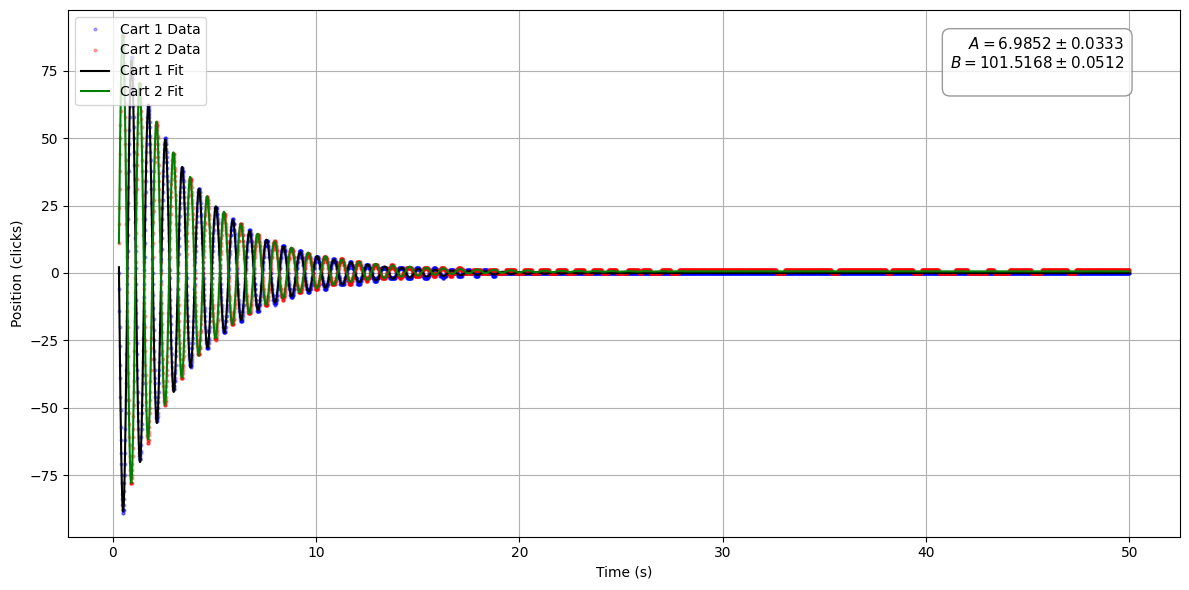


Processing data_csvs/nisui_110_same(1).txt...
--- Fit Results ---
Damping (gamma): 0.2671 ± 0.0003
Angular freq 1 (w1): 4.3042 ± 0.0003
Angular freq 2 (w2): 7.5522 ± 0.0119
Amplitude A: 117.8280 ± 0.1098
Amplitude B: 3.0115 ± 0.0679


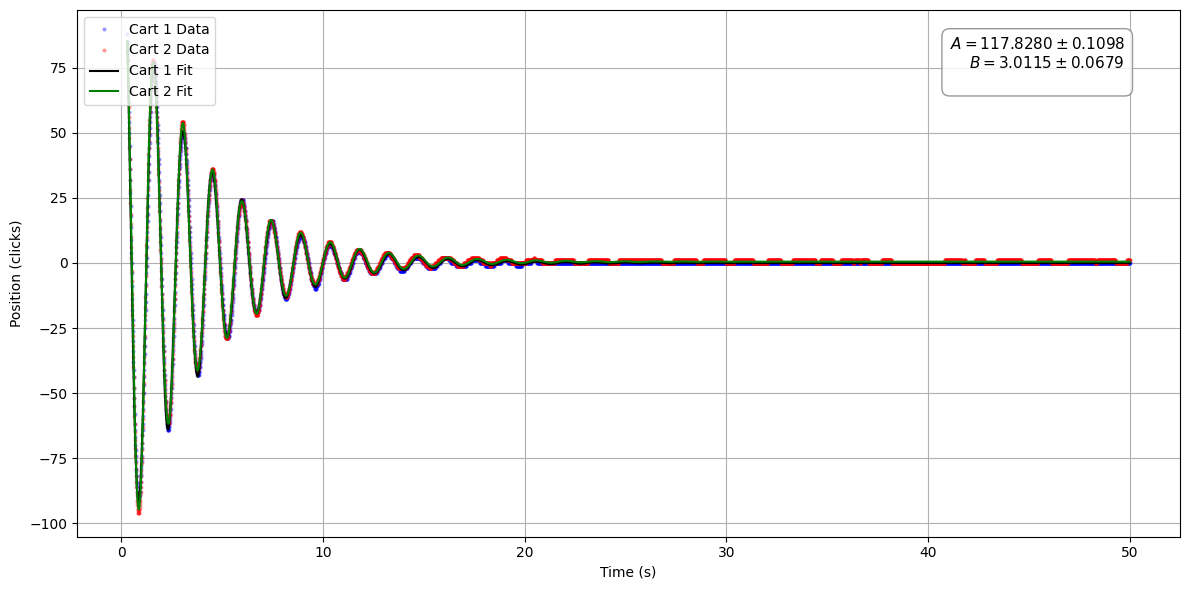


Processing data_csvs/nisui_120_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2806 ± 0.0004
Angular freq 1 (w1): 4.1982 ± 0.0061
Angular freq 2 (w2): 7.5731 ± 0.0004
Amplitude A: -8.7987 ± 0.0902
Amplitude B: 131.9302 ± 0.1418


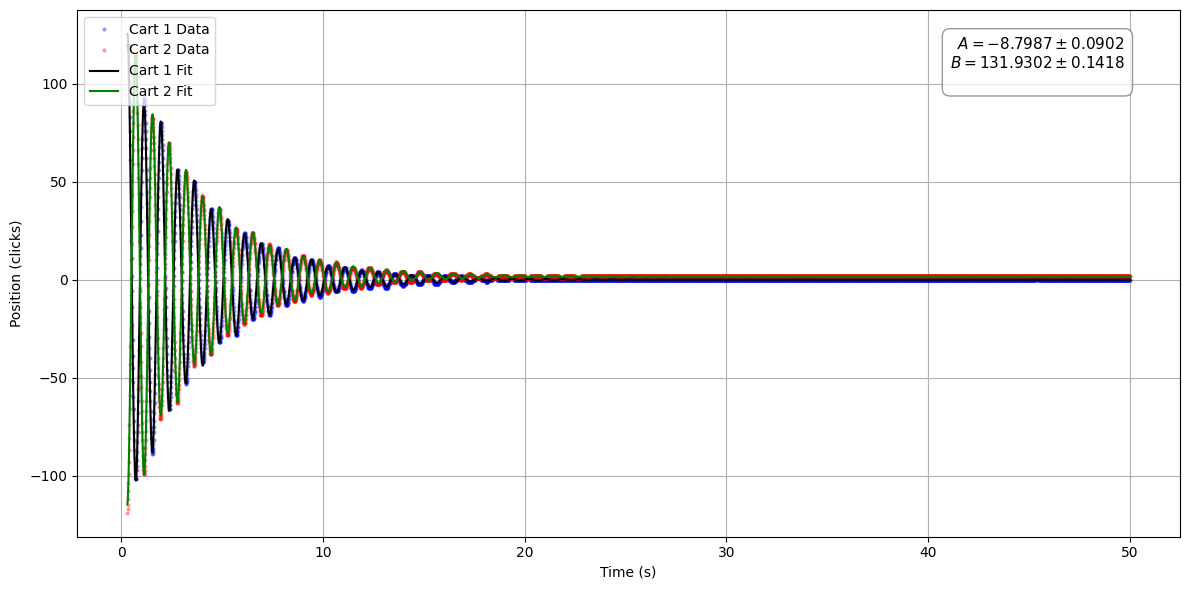


Processing data_csvs/nisui_120_same.txt...
--- Fit Results ---
Damping (gamma): 0.2675 ± 0.0003
Angular freq 1 (w1): 4.3027 ± 0.0003
Angular freq 2 (w2): 7.6442 ± 0.0139
Amplitude A: 140.9432 ± 0.1289
Amplitude B: 3.0302 ± 0.0809


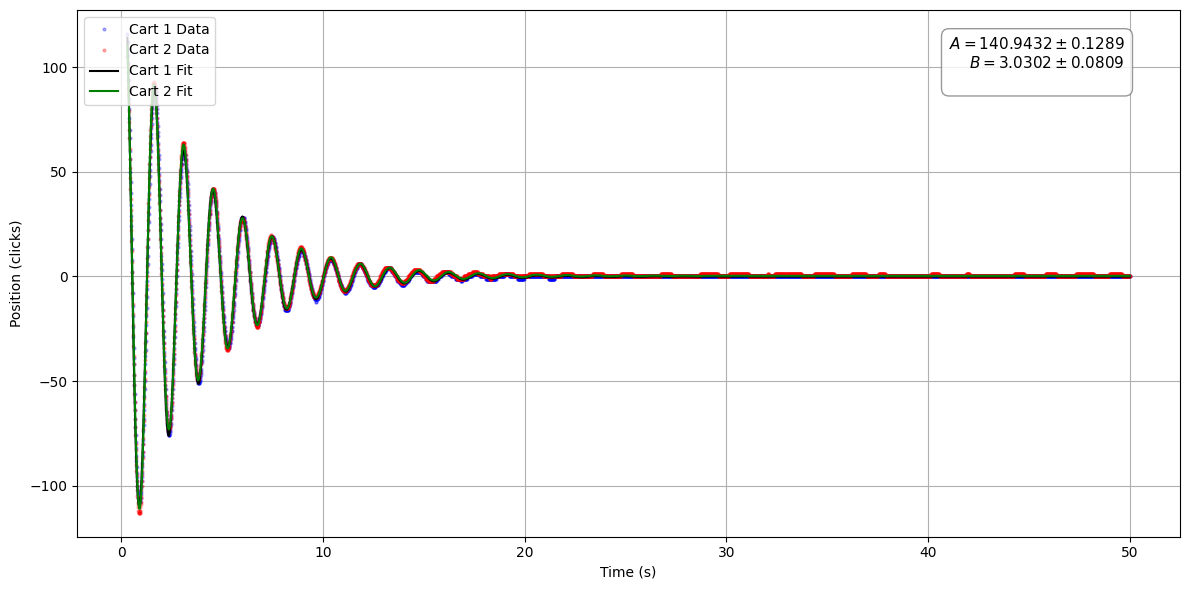


Processing data_csvs/nisui_130_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2790 ± 0.0004
Angular freq 1 (w1): 4.2064 ± 0.0067
Angular freq 2 (w2): 7.5745 ± 0.0004
Amplitude A: -7.3086 ± 0.0823
Amplitude B: 116.0566 ± 0.1349


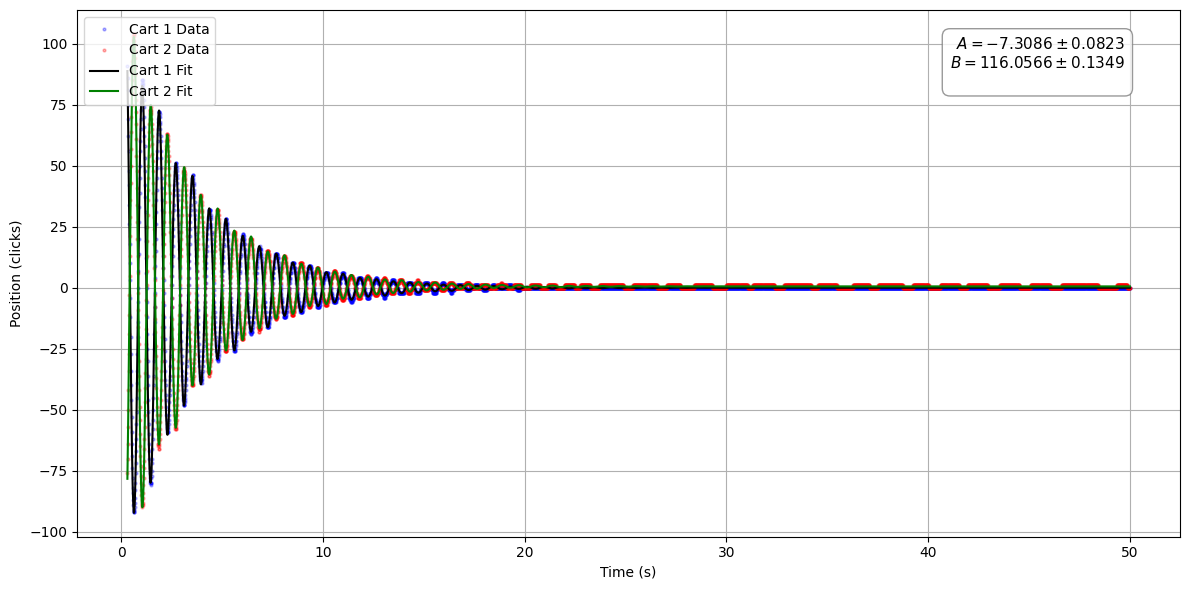


Processing data_csvs/nisui_1_fixed_fixed.txt...
--- Fit Results ---
Damping (gamma): 0.2660 ± 0.0003
Angular freq 1 (w1): 4.3096 ± 0.0003
Angular freq 2 (w2): 7.5982 ± 0.0225
Amplitude A: -107.3808 ± 0.0919
Amplitude B: 1.3674 ± 0.0595


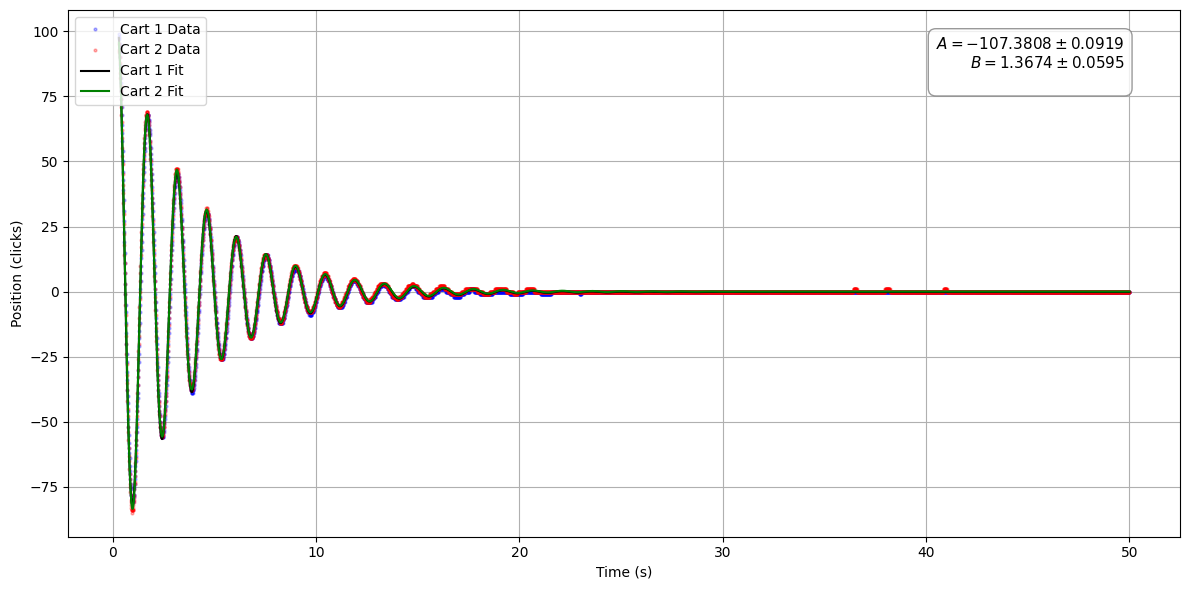


Processing data_csvs/nisui_1_fixed_same.txt...
--- Fit Results ---
Damping (gamma): 0.2659 ± 0.0002
Angular freq 1 (w1): 4.3091 ± 0.0002
Angular freq 2 (w2): 4.3676 ± 0.0050
Amplitude A: 103.7999 ± 0.0698
Amplitude B: -4.6514 ± 0.0416


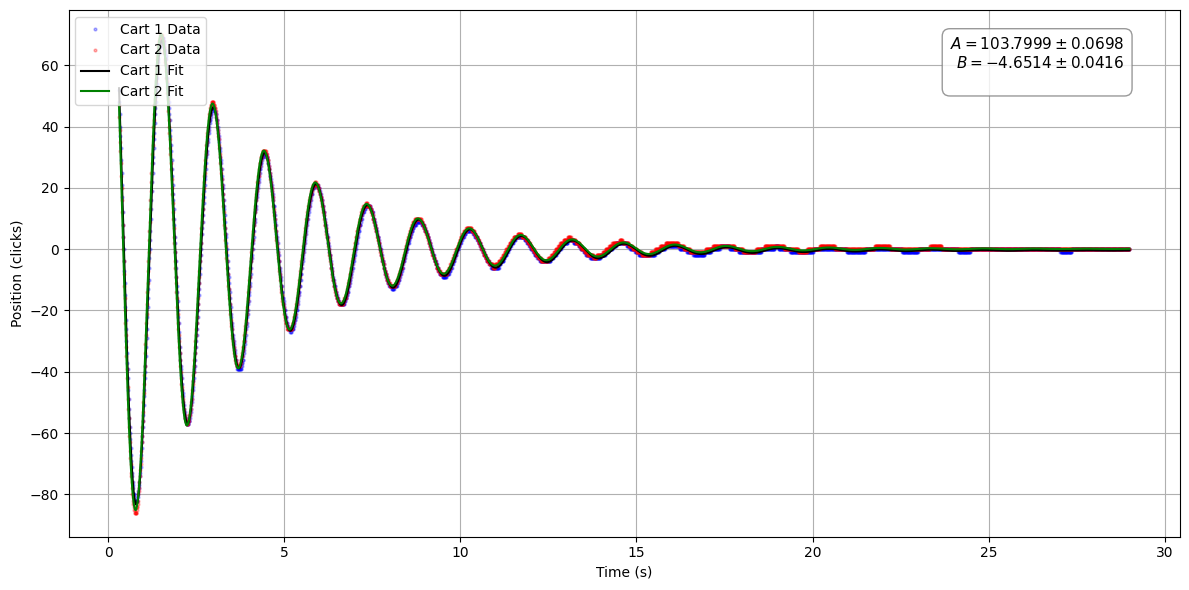


Processing data_csvs/nisui_80_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2766 ± 0.0004
Angular freq 1 (w1): 4.3129 ± 0.0074
Angular freq 2 (w2): 7.5796 ± 0.0004
Amplitude A: 4.7153 ± 0.0597
Amplitude B: 79.3901 ± 0.0916


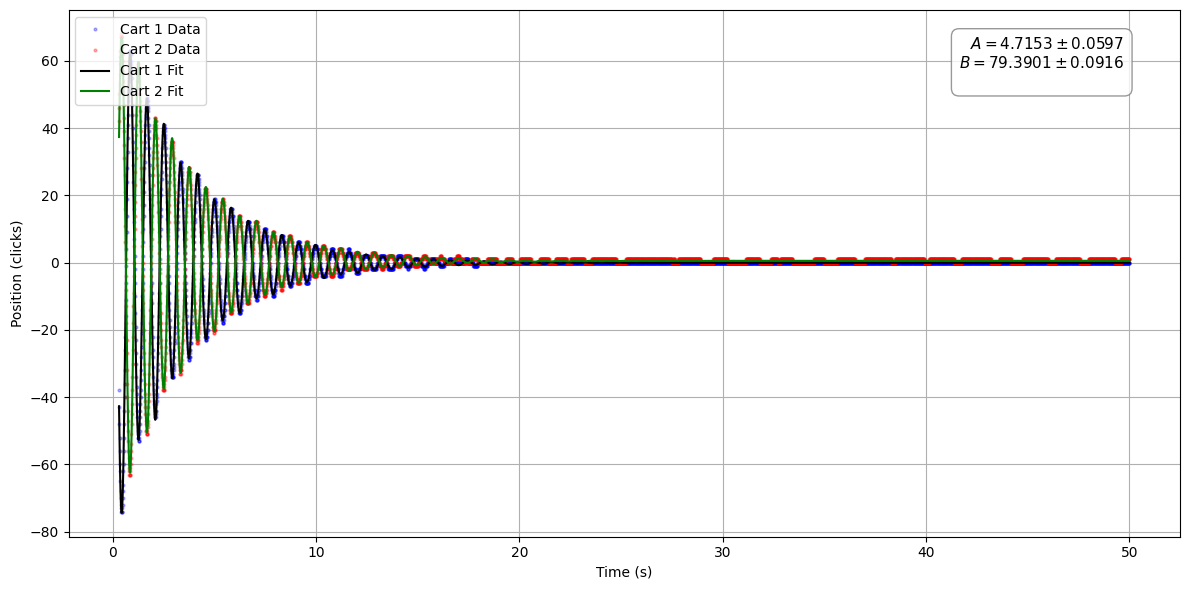


Processing data_csvs/nisui_80_same.txt...
--- Fit Results ---
Damping (gamma): 0.2678 ± 0.0003
Angular freq 1 (w1): 4.3107 ± 0.0003
Angular freq 2 (w2): 7.4442 ± 0.0115
Amplitude A: 82.7263 ± 0.0756
Amplitude B: 2.1974 ± 0.0458


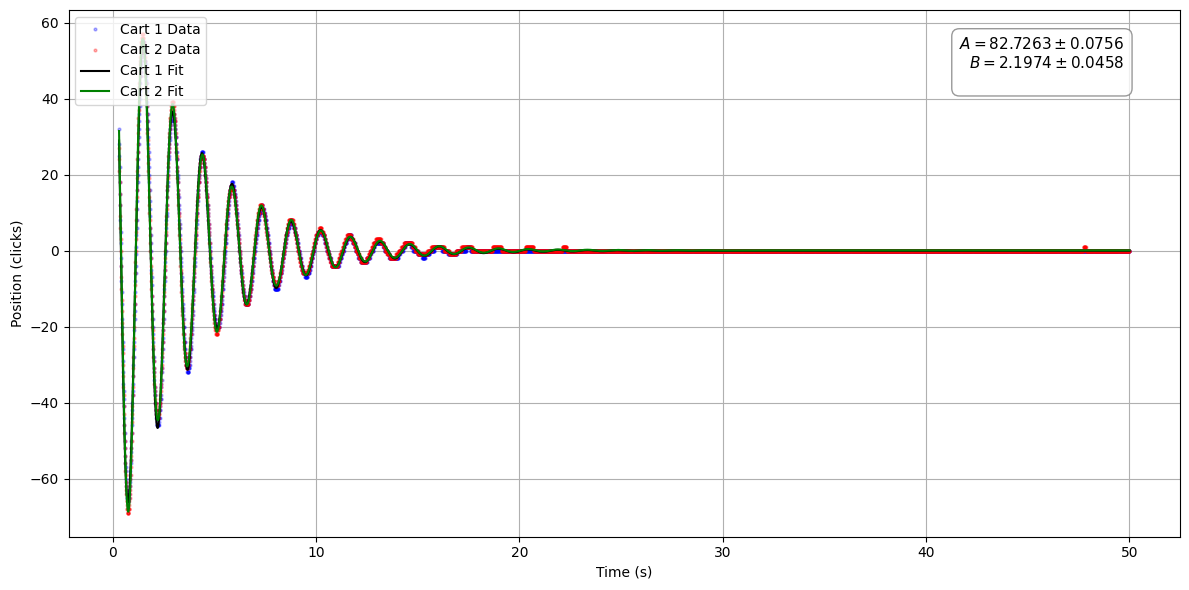


Processing data_csvs/nisui_90_anti.txt...
--- Fit Results ---
Damping (gamma): 0.2776 ± 0.0002
Angular freq 1 (w1): 7.5894 ± 0.0036
Angular freq 2 (w2): 7.5774 ± 0.0002
Amplitude A: 6.2037 ± 0.0388
Amplitude B: 94.7042 ± 0.0625


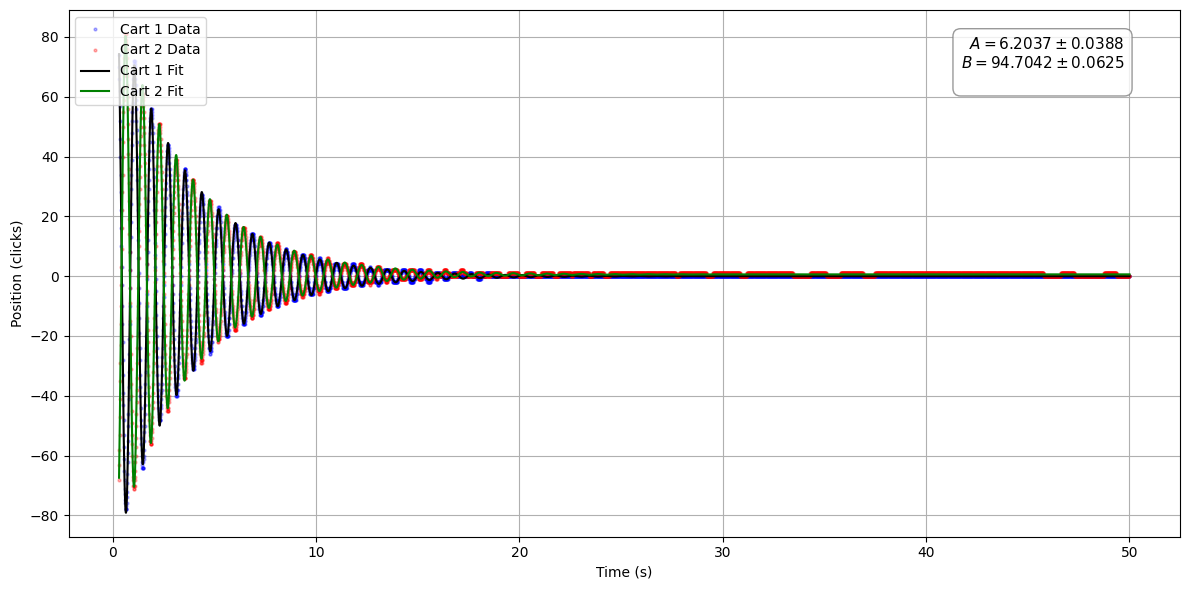

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

results_dict = []
# 1. Define the coupled equations to fit simultaneously
def coupled_oscillators(t_combo, gamma, w1, w2, A, B, phi1, phi2, C1, C2):
    N = len(t_combo) // 2
    t = t_combo[:N]

    # General solution for coupled damped oscillators
    x1 = np.exp(-gamma * t) * (A * np.cos(w1 * t + phi1) + B * np.cos(w2 * t + phi2)) + C1
    x2 = np.exp(-gamma * t) * (A * np.cos(w1 * t + phi1) - B * np.cos(w2 * t + phi2)) + C2

    return np.concatenate((x1, x2))

# 2. Load the data file
# Make sure the 'data_csvs' directory exists in the same folder as this script
data_files = ["data_csvs/" + file for file in os.listdir("data_csvs") if file.endswith('.txt') or file.endswith('.csv')]

for data_file in data_files:
    print(f"\nProcessing {data_file}...")

    df = pd.read_csv(data_file, sep=r'\s+', comment='#', names=['index', 'time', 'cart1', 'cart2'])
    df = df[df['time'] > 0.3]
    t = df['time'].values
    x1_data = df['cart1'].values
    x2_data = df['cart2'].values

    # Combine the data arrays for simultaneous fitting
    t_combo = np.concatenate((t, t))
    x_combo_data = np.concatenate((x1_data, x2_data))

    # 3. Provide initial guesses [gamma, w1, w2, A, B, phi1, phi2, C1, C2]
    initial_guess = [0.05, 5.0, 7.0, 10.0, 10.0, 0, 0, np.mean(x1_data), np.mean(x2_data)]

    # Variables to hold text for the plot
    fit_text = ""

    # 4. Perform the curve fit
    try:
        popt, pcov = curve_fit(coupled_oscillators, t_combo, x_combo_data, p0=initial_guess, maxfev=10000)

        # Unpack the fitted parameters
        gamma_fit, w1_fit, w2_fit, A_fit, B_fit, phi1_fit, phi2_fit, C1_fit, C2_fit = popt

        # Calculate standard deviation errors from the covariance matrix
        perr = np.sqrt(np.diag(pcov))
        gamma_err, w1_err, w2_err, A_err, B_err, phi1_err, phi2_err, C1_err, C2_err = perr

        print("--- Fit Results ---")
        print(f"Damping (gamma): {gamma_fit:.4f} ± {gamma_err:.4f}")
        print(f"Angular freq 1 (w1): {w1_fit:.4f} ± {w1_err:.4f}")
        print(f"Angular freq 2 (w2): {w2_fit:.4f} ± {w2_err:.4f}")
        print(f"Amplitude A: {A_fit:.4f} ± {A_err:.4f}")
        print(f"Amplitude B: {B_fit:.4f} ± {B_err:.4f}")

        # 5. Calculate fitted curves for plotting
        x1_fit = np.exp(-gamma_fit * t) * (A_fit * np.cos(w1_fit * t + phi1_fit) + B_fit * np.cos(w2_fit * t + phi2_fit)) + C1_fit
        x2_fit = np.exp(-gamma_fit * t) * (A_fit * np.cos(w1_fit * t + phi1_fit) - B_fit * np.cos(w2_fit * t + phi2_fit)) + C2_fit

        # Format text to display on the plot
        fit_text = (
            # f"$\\gamma = {gamma_fit:.4f} \\pm {gamma_err:.4f}$\n"
            # f"$\\omega_1 = {w1_fit:.4f} \\pm {w1_err:.4f}$\n"
            f"$A = {A_fit:.4f} \\pm {A_err:.4f}$\n"
            f"$B = {B_fit:.4f} \\pm {B_err:.4f}$\n"
            # f"$\\omega_2 = {w2_fit:.4f} \\pm {w2_err:.4f}$"
        )

    except RuntimeError:
        print("Curve fit failed to converge. Try adjusting the initial_guess parameters.")
        x1_fit, x2_fit = None, None

    # 6. Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(t, x1_data, 'b.', label='Cart 1 Data', alpha=0.3, markersize=4)
    plt.plot(t, x2_data, 'r.', label='Cart 2 Data', alpha=0.3, markersize=4)

    if x1_fit is not None:
        plt.plot(t, x1_fit, 'k-', label='Cart 1 Fit', linewidth=1.5)
        plt.plot(t, x2_fit, 'g-', label='Cart 2 Fit', linewidth=1.5)

        # Add the parameter and error text box to the plot
        plt.text(0.95, 0.95, fit_text, transform=plt.gca().transAxes,
                 fontsize=11, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

    plt.xlabel('Time (s)')
    plt.ylabel('Position (clicks)')
    # plt.title(f'Coupled Damped Harmonic Oscillators Fit ({os.basename(data_file)})')
    plt.legend(loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    results_dict.append((data_file, np.abs(A_fit), A_err, np.abs(B_fit), B_err, gamma_fit, gamma_err, w1_fit, w1_err, w2_fit, w2_err))
    # plt.savefig(f"fit_figures/{data_file.split('/')[-1]}")

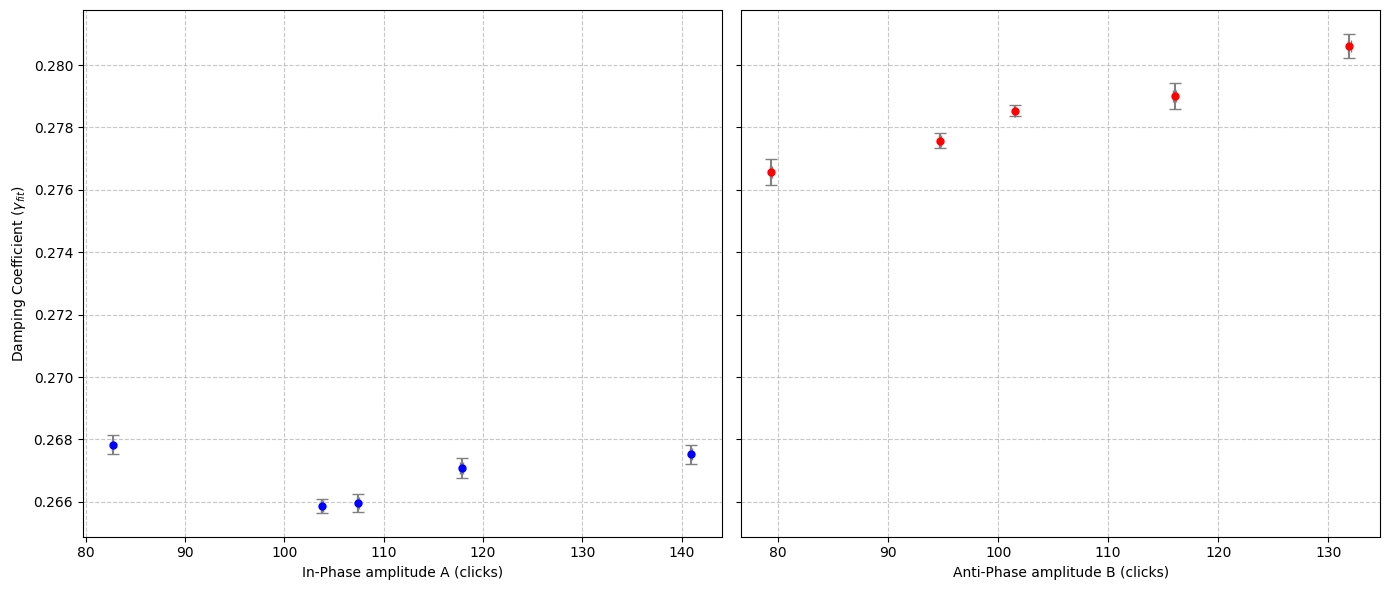

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert your list of tuples into a Pandas DataFrame
columns = ['file_name', 'A_fit', 'A_err', 'B_fit', 'B_err', 'gamma_fit', 'gamma_err', 'w1_fit', 'w1_err', 'w2_fit', 'w2_err']
df = pd.DataFrame(results_dict, columns=columns)

# 2. Filter the data into two separate DataFrames based on dominance
df_A_dominant = df[df['A_fit'] > df['B_fit']]
df_B_dominant = df[df['B_fit'] > df['A_fit']]

# 3. Create the plots side-by-side (Notice sharey=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot 1: A is dominant (gamma vs A)
ax1.errorbar(df_A_dominant['A_fit'], df_A_dominant['gamma_fit'],
             xerr=df_A_dominant['A_err'], yerr=df_A_dominant['gamma_err'],
             fmt='o', color='blue', ecolor='gray', capsize=4, markersize=5)
ax1.set_xlabel('In-Phase amplitude A (clicks)')
ax1.set_ylabel(r'Damping Coefficient ($\gamma_{fit}$)')
# ax1.set_title(r'$\gamma$ vs $A$ (Where $A > B$)')
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot 2: B is dominant (gamma vs B)
ax2.errorbar(df_B_dominant['B_fit'], df_B_dominant['gamma_fit'],
             xerr=df_B_dominant['B_err'], yerr=df_B_dominant['gamma_err'],
             fmt='o', color='red', ecolor='gray', capsize=4, markersize=5)
ax2.set_xlabel('Anti-Phase amplitude B (clicks)')
# ax2.set_title(r'$\gamma$ vs $B$ (Where $B > A$)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

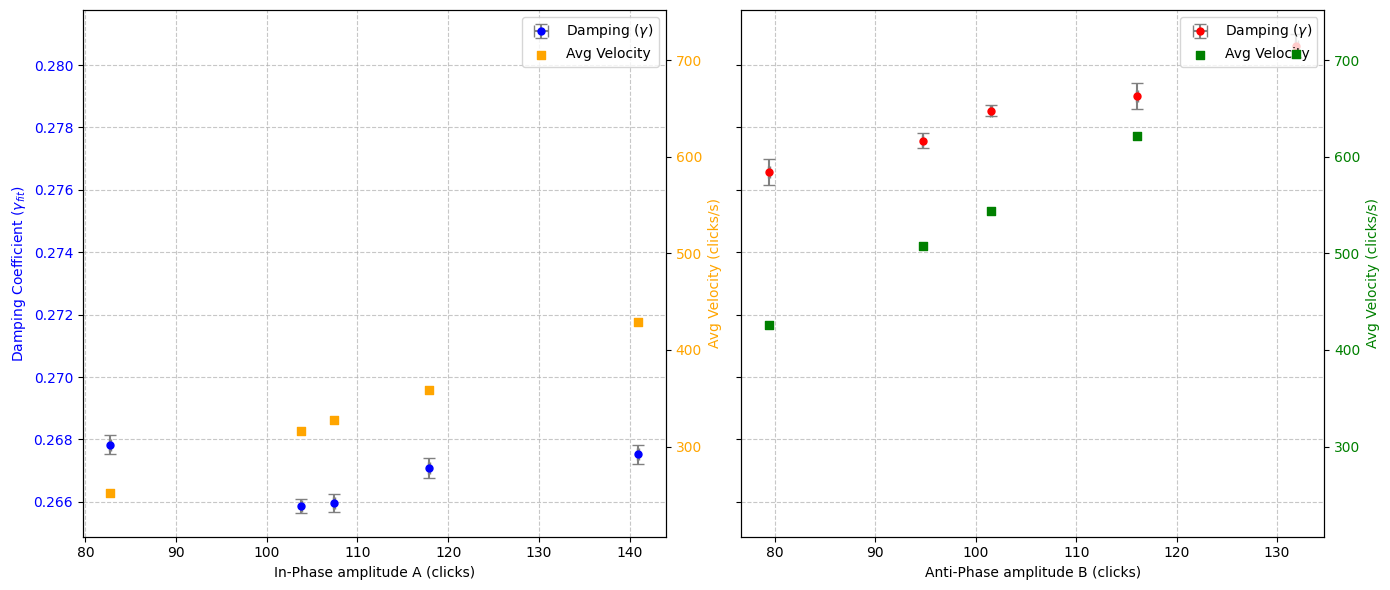

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Convert your list of tuples into a Pandas DataFrame
columns = ['file_name', 'A_fit', 'A_err', 'B_fit', 'B_err', 'gamma_fit', 'gamma_err', 'w1_fit', 'w1_err', 'w2_fit', 'w2_err']
df = pd.DataFrame(results_dict, columns=columns)

# Calculate the average (RMS) velocity for both modes
# Formula: v_rms = (Amplitude * Angular Frequency) / sqrt(2)
df['v_avg_A'] = (df['A_fit'] * df['w1_fit']) / np.sqrt(2)
df['v_avg_B'] = (df['B_fit'] * df['w2_fit']) / np.sqrt(2)

# 2. Filter the data into two separate DataFrames based on dominance
df_A_dominant = df[df['A_fit'] > df['B_fit']]
df_B_dominant = df[df['B_fit'] > df['A_fit']]

# 3. Create the plots side-by-side (Notice sharey=True for the primary left axes)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# ==========================================
# Plot 1: A is dominant (In-Phase Mode)
# ==========================================
# Primary Axis (Left - Gamma)
ax1.errorbar(df_A_dominant['A_fit'], df_A_dominant['gamma_fit'],
             xerr=df_A_dominant['A_err'], yerr=df_A_dominant['gamma_err'],
             fmt='o', color='blue', ecolor='gray', capsize=4, markersize=5, label=r'Damping ($\gamma$)')
ax1.set_xlabel('In-Phase amplitude A (clicks)')
ax1.set_ylabel(r'Damping Coefficient ($\gamma_{fit}$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)

# Secondary Axis (Right - Velocity)
ax1_twin = ax1.twinx()
ax1_twin.scatter(df_A_dominant['A_fit'], df_A_dominant['v_avg_A'],
                 color='orange', marker='s', s=30, label='Avg Velocity')
ax1_twin.set_ylabel('Avg Velocity (clicks/s)', color='orange')
ax1_twin.tick_params(axis='y', labelcolor='orange')

# Combine legends for ax1
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_1_twin, labels_1_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(lines_1 + lines_1_twin, labels_1 + labels_1_twin, loc='upper right')

# ==========================================
# Plot 2: B is dominant (Anti-Phase Mode)
# ==========================================
# Primary Axis (Left - Gamma)
ax2.errorbar(df_B_dominant['B_fit'], df_B_dominant['gamma_fit'],
             xerr=df_B_dominant['B_err'], yerr=df_B_dominant['gamma_err'],
             fmt='o', color='red', ecolor='gray', capsize=4, markersize=5, label=r'Damping ($\gamma$)')
ax2.set_xlabel('Anti-Phase amplitude B (clicks)')
ax2.tick_params(axis='y', labelcolor='red') # Left labels are hidden by sharey, but color ticks for clarity
ax2.grid(True, linestyle='--', alpha=0.7)

# Secondary Axis (Right - Velocity)
ax2_twin = ax2.twinx()
ax2_twin.scatter(df_B_dominant['B_fit'], df_B_dominant['v_avg_B'],
                 color='green', marker='s', s=30, label='Avg Velocity')
ax2_twin.set_ylabel('Avg Velocity (clicks/s)', color='green')
ax2_twin.tick_params(axis='y', labelcolor='green')

# Sync the Y-limits of the two secondary (right) axes so they are also comparable
vel_min = min(df_A_dominant['v_avg_A'].min(), df_B_dominant['v_avg_B'].min())
vel_max = max(df_A_dominant['v_avg_A'].max(), df_B_dominant['v_avg_B'].max())
padding = (vel_max - vel_min) * 0.1
ax1_twin.set_ylim(vel_min - padding, vel_max + padding)
ax2_twin.set_ylim(vel_min - padding, vel_max + padding)

# Combine legends for ax2
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_2_twin, labels_2_twin = ax2_twin.get_legend_handles_labels()
ax2.legend(lines_2 + lines_2_twin, labels_2 + labels_2_twin, loc='upper right')

plt.tight_layout()
plt.show()